# **Timestamp**

In [27]:
from glob import glob
import os

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

%matplotlib widget
plt.close('all')

**Data**\
change folder and suffix

In [28]:
folder = 'C:\\Users\\Leah\\Documents\\OnixData\\TimestampTesting\\Test1\\'

suffix = '0'

**Metadata**

In [29]:
dtMeta = {'names': ('time', 'acq_clk_hz', 'block_read_sz', 'block_write_sz'),
      'formats': ('datetime64[us]', 'u4', 'u4', 'u4')}
meta = np.genfromtxt(folder + 'start-time_' + suffix + '.csv', delimiter=',', dtype=dtMeta)
print(f"Recording was started at {meta['time']} GMT")

Recording was started at 2025-06-05T19:08:06.944563 GMT


**Time from analog acq clock**

In [30]:
analog_clock_time = {}
analog_clock_time['time'] = np.fromfile(folder + 'analog-clock_' + suffix + '.raw', dtype=np.uint64) / meta['acq_clk_hz']
analog_clock_time['raw_time'] = np.fromfile(folder + 'analog-clock_' + suffix + '.raw', dtype=np.uint64)

**Timestamp and event**

In [31]:
dtTimestamp = {'names': ('time', 'word_out'),
      'formats': ('datetime64[us]', 'u4')}
timestamp = np.genfromtxt(folder + 'timestamp-time_' + suffix + '.csv', delimiter=',', dtype=dtTimestamp)
print(f"First TTL out was at {timestamp['time'][0]} GMT and was {timestamp['word_out'][0]}")

First TTL out was at 2025-06-05T19:08:06.948940 GMT and was 100


**Event**

In [32]:
event = np.genfromtxt(folder + 'analog-time_' + suffix + '.csv', delimiter=',')

**Utility Functions**

In [33]:
def edge(data, thresh, edge):
    sign = data >= thresh
    pos = np.where(np.convolve(sign, [1, -1]) == edge)
    return pos

**Plots**

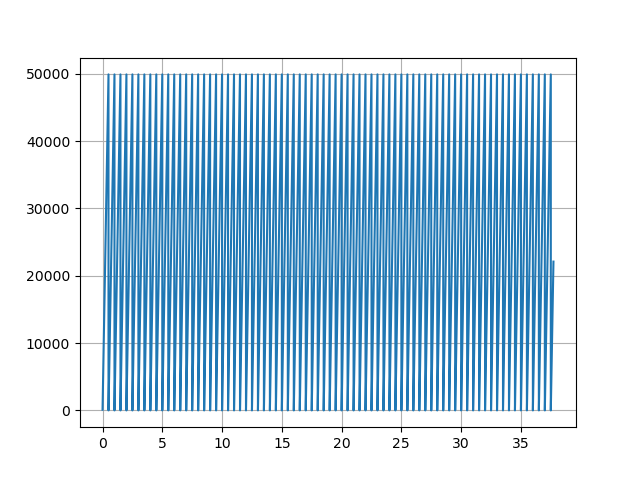

In [37]:
plt.figure()
plt.plot(analog_clock_time['time'][0::100], event)
plt.grid(True)
plt.show()

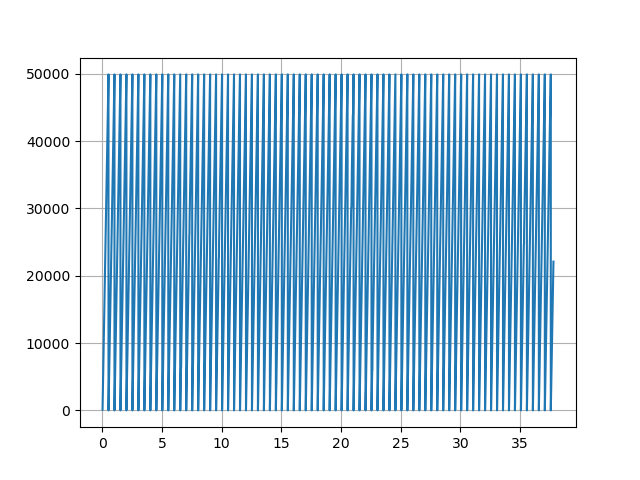

In [36]:
# Z score crossing 
sync_time = (timestamp['time']) - (meta['time'])
ttl_time = sync_time.astype(np.double, casting='unsafe') / 1e6

word_out = timestamp['word_out']

plt.figure()
plt.plot(ttl_time, word_out)
plt.grid(True)
plt.show()

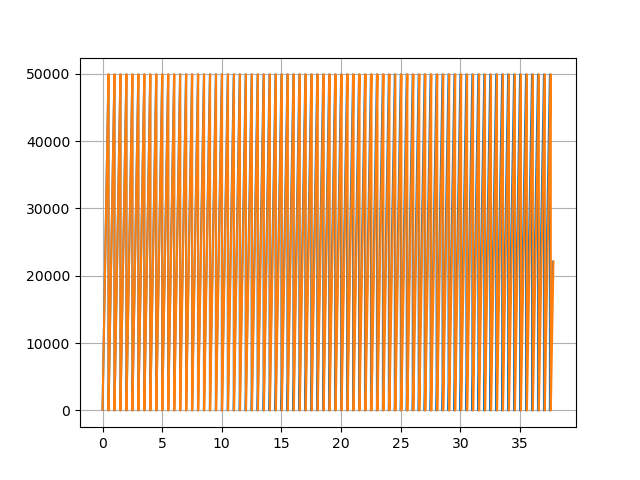

In [39]:
plt.figure()
plt.plot(analog_clock_time['time'][0::100], event)
plt.plot(ttl_time, word_out)
plt.grid(True)
plt.show()

In [ ]:
# TLL word latencies 
falling_edge = edge(word_out,1,-1)

rising_time_stamp = ttl_time[rising_edge]
falling_time_stamp = ttl_time[falling_edge]

rising_time_stamp_dif = rising_time_stamp[1:] - rising_time_stamp[:-1]
falling_time_stamp_dif = falling_time_stamp[1:] - falling_time_stamp[:-1]

# Using TTL timestamps
print("rising and falling times in seconds from timestamps")
print(rising_time_stamp_dif)
print(falling_time_stamp_dif)

# Alligned to analog time
rising_time_analog = analog_time[rising_edge]
falling_time_analog = analog_time[falling_edge]

rising_time_analog_dif = rising_time_analog[1:] - rising_time_analog[:-1]
falling_time_analog_dif = falling_time_analog[1:] - falling_time_analog[:-1]

print("\nrising and falling times in seconds alligned to analog time")
print(rising_time_analog_dif)
print(falling_time_analog_dif)

# TTL timestamp duration
ttl_dur_stamps = falling_time_stamp - rising_time_stamp
ttl_dur_analog = falling_time_analog - rising_time_analog

print("\nTTL durations with respect to timestamps and analog time")
print(ttl_dur_stamps)
print(ttl_dur_analog)